<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
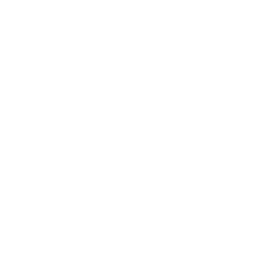
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Visit Data Accumulation to Monthly Intervals</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Trial Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

In a Phase II hepatology safety sub-study, patients return for protocol-scheduled
laboratory draws roughly every two weeks, but actual visit dates drift by several
days around each target. Irregular sampling like this cannot be fed directly into a
repeated-measures or trend model, which expects observations on a fixed time grid.

This notebook uses `PROC TIMESERIES` with `INTERVAL=MONTH` and `ACCUMULATE=MEAN` to
collapse the irregular visit-level lab results of a 9-patient cohort onto a uniform
monthly axis, taking the mean of every measurement that falls inside each calendar
month. The procedure runs independently for each patient/analyte `BY` group, and
`PRINT=DESCSTATS` reports the descriptive statistics of each accumulated series.

The accumulated series exposes a clear safety signal: every patient's monthly mean
**ALT** rises over the treatment period - the cohort month-1 mean of 30.6 U/L climbs
to a month-10 mean of 51.7 U/L - and **AST** follows the same upward path, while
**creatinine** and **hemoglobin** stay flat at their baseline levels. Every count and
statistic quoted below is taken directly from the executed output of this notebook.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.VISIT_LABS | Irregular visit-level lab results: 9 patients, 20 fortnightly visits each, 4 analytes (ALT, AST, CREAT, HGB) | 720 |
| WORK.MONTHLY_LABS | Monthly-accumulated series produced by PROC TIMESERIES (per patient/analyte, ~10 calendar months) | 348 |

---

In [1]:
/* --------------------------------------------------------
   Generate irregular clinical visit lab observations.
   9 patients, 20 visits each, scheduled fortnightly but
   with +/- 5 day date drift. ALT and AST drift upward over
   the treatment period (a drug-induced transaminase signal);
   creatinine and hemoglobin stay at baseline.
   -------------------------------------------------------- */
data work.visit_labs;
    call streaminit(42);
    format visit_date date9.;
    array lab_tests[4] $10 _temporary_ ('ALT' 'AST' 'CREAT' 'HGB');
    do patient_id = 1 to 9;
        usubjid = cat('HEP-', put(patient_id, z3.));
        base_date = '06JAN2025'd + int(rand('uniform') * 7);
        do visit_num = 1 to 20;
            /* scheduled every 14 days; actual date drifts +/- 5 days */
            visit_date = base_date + (visit_num - 1) * 14
                         + int(rand('uniform') * 11) - 5;
            month_idx = visit_num / 2;   /* approx month into study */
            do t = 1 to 4;
                lab_test = lab_tests[t];
                if lab_test = 'ALT' then
                    lab_value = round(rand('normal', 30, 6) + month_idx * 2.2, 0.1);
                else if lab_test = 'AST' then
                    lab_value = round(rand('normal', 26, 5) + month_idx * 1.6, 0.1);
                else if lab_test = 'CREAT' then
                    lab_value = round(rand('normal', 0.95, 0.12), 0.01);
                else
                    lab_value = round(rand('normal', 13.2, 1.1), 0.1);
                output;
            end;
        end;
    end;
    drop t base_date month_idx;
run;

NOTE: DATA work.visit_labs


NOTE: Wrote work.visit_labs (720 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Per-patient visit frequency and observation window.
   Each patient contributes 20 visits x 4 analytes = 80 rows.
   -------------------------------------------------------- */
proc sql;
    select usubjid,
           count(distinct visit_date) as n_visits,
           count(*) as n_observations,
           min(visit_date) as first_visit format=date9.,
           max(visit_date) as last_visit  format=date9.
    from work.visit_labs
    group by usubjid
    order by usubjid;
quit;

usubjid  n_visits  n_observations  first_visit  last_visit
-------  --------  --------------  -----------  ----------
HEP-001        20              80    08JAN2025   07OCT2025
HEP-002        20              80    04JAN2025   30SEP2025
HEP-003        20              80    12JAN2025   04OCT2025
HEP-004        20              80    14JAN2025   01OCT2025
HEP-005        20              80    14JAN2025   07OCT2025
HEP-006        20              80    08JAN2025   28SEP2025
HEP-007        20              80    12JAN2025   30SEP2025
HEP-008        20              80    15JAN2025   04OCT2025
HEP-009        20              80    11JAN2025   02OCT2025


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

NOTE: PROC SGPLOT data=work.visit_labs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


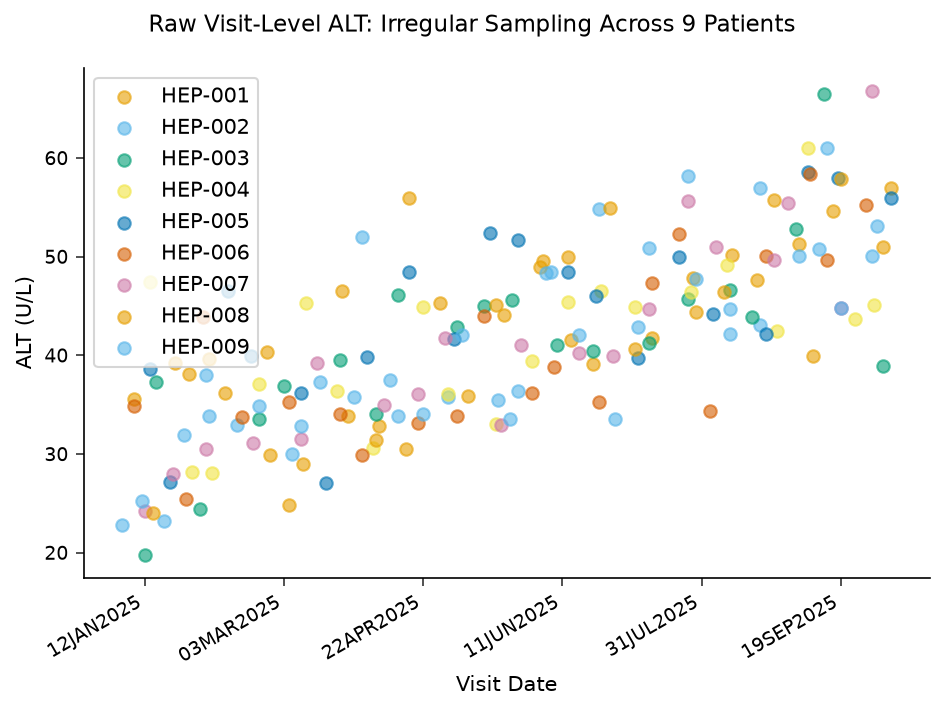

In [3]:
/* --------------------------------------------------------
   Raw visit-level ALT: irregular sampling, upward drift.
   One marker per visit, colored by patient.
   -------------------------------------------------------- */
proc sgplot data=work.visit_labs(where=(lab_test='ALT'));
    scatter x=visit_date y=lab_value / group=usubjid
        transparency=0.4 markerattrs=(symbol=circlefilled size=6);
    xaxis label='Visit Date';
    yaxis label='ALT (U/L)';
    title 'Raw Visit-Level ALT: Irregular Sampling Across 9 Patients';
run;

---

In [4]:
/* --------------------------------------------------------
   Sort by patient, analyte and date for PROC TIMESERIES.
   -------------------------------------------------------- */
proc sort data=work.visit_labs;
    by usubjid lab_test visit_date;
run;

NOTE: PROC SORT data=work.visit_labs

NOTE: Read 720 rows from work.visit_labs.
NOTE: Wrote work.visit_labs (720 rows, 6 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Accumulate irregular visit data onto a monthly grid.
   ACCUMULATE=MEAN takes the mean of every value falling in
   each calendar month, per patient/analyte BY group.
   PRINT=DESCSTATS reports each accumulated series.
   -------------------------------------------------------- */
proc timeseries data=work.visit_labs
                out=work.monthly_labs
                print=(descstats);
    id visit_date interval=month
       accumulate=mean
       setmissing=missing;
    var lab_value;
    by usubjid lab_test;
run;

NOTE: PROC TIMESERIES data=work.visit_labs

NOTE: Processing BY group: usubjid=HEP-001, lab_test=ALT
NOTE: Variable: lab_value
NOTE: Number of Observations: 10
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Descriptive Statistics:
NOTE: Statistic          Value
NOTE: ----------    ----------
NOTE: Mean             44.4600
NOTE: Std Dev           7.3872
NOTE: Minimum          31.4000
NOTE: Maximum          57.0000
NOTE: N                     10
NOTE: N Missing              0
NOTE: Processing BY group: usubjid=HEP-001, lab_test=AST
NOTE: Variable: lab_value
NOTE: Number of Observations: 10
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Descriptive Statistics:
NOTE: Statistic          Value
NOTE: ----------    ----------
NOTE: Mean             35.6433
NOTE: Std Dev           8.1311
NOTE: Minimum          25.4333
NOTE: Maximum          46.2000
NOTE: N                     10
NOTE: N Missing              0
NOTE: Processing BY group: usubjid=HEP-0

In [6]:
/* --------------------------------------------------------
   Re-attach the DATE9. format to the accumulated time ID so
   downstream displays show calendar months rather than the
   raw SAS date value.
   -------------------------------------------------------- */
data work.monthly_labs;
    set work.monthly_labs;
    format visit_date date9.;
run;

NOTE: DATA work.monthly_labs


NOTE: Read 348 rows from work.monthly_labs.
NOTE: Wrote work.monthly_labs (348 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [7]:
/* --------------------------------------------------------
   Verify the accumulated series: one mean per analyte across
   all patient-months, and confirm no missing monthly buckets.
   -------------------------------------------------------- */
proc means data=work.monthly_labs n nmiss mean std min max;
    class lab_test;
    var lab_value;
    title 'Monthly Accumulated Lab Value Summary';
run;

                                         Monthly Accumulated Lab Value Summary                                          

                                                  The MEANS Procedure

                                             Analysis Variable : lab_value

        LAB_TEST          N Obs         N Miss           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------
        ALT                  87              0     41.8373563      8.2341336     23.0000000     59.6500000
        AST                  87              0     34.2775862      6.0186660     23.7500000     47.1500000
        CREAT                87              0      0.9315709      0.0872377      0.6200000      1.1150000
        HGB                  87              0     13.1942529      0.7535867     11.6500000     15.0500000
        ---------------------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                         Monthly Accumulated Lab Value Summary                                          



NOTE: PROC SGPLOT data=work.monthly_labs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


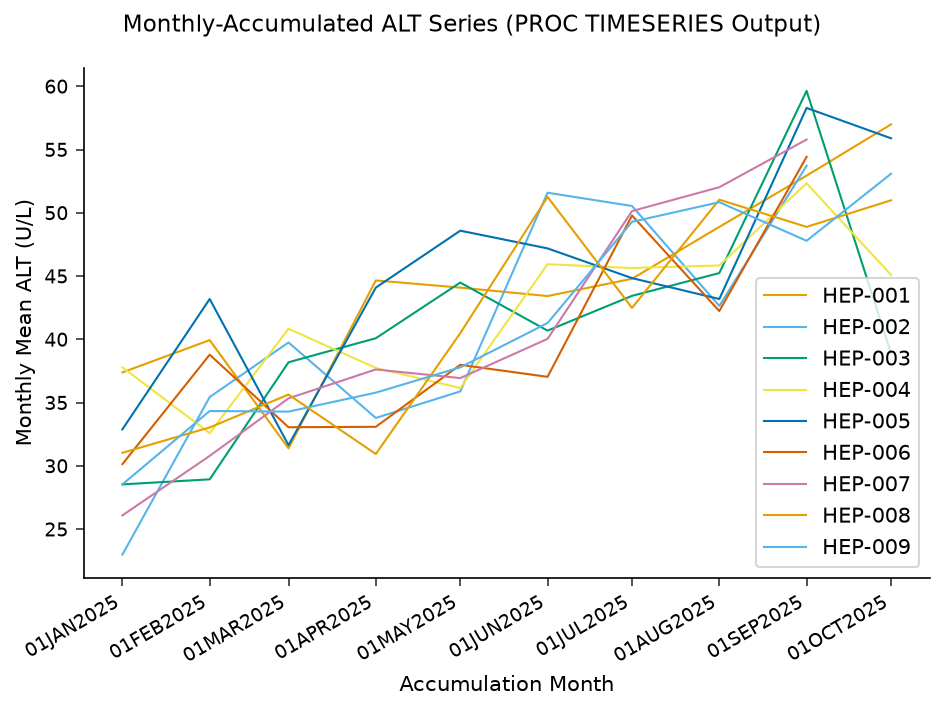

In [8]:
/* --------------------------------------------------------
   Accumulated monthly ALT series: one point per calendar
   month per patient, on a regular grid. The upward drift
   that was obscured by irregular sampling is now explicit.
   -------------------------------------------------------- */
proc sgplot data=work.monthly_labs(where=(lab_test='ALT'));
    series x=visit_date y=lab_value / group=usubjid
        markers markerattrs=(symbol=circlefilled size=5)
        lineattrs=(thickness=1);
    xaxis label='Accumulation Month';
    yaxis label='Monthly Mean ALT (U/L)';
    title 'Monthly-Accumulated ALT Series (PROC TIMESERIES Output)';
run;

---

### Interpretation

`PROC TIMESERIES` accumulated the 720 irregular visit-level observations onto a
uniform monthly axis, processing each of the 36 patient/analyte `BY` groups
independently. Because patients were sampled roughly fortnightly from early January
to early October 2025, each `BY` group collapses to 9 or 10 monthly buckets, and the
output dataset `WORK.MONTHLY_LABS` holds **348 rows** with **zero missing months** -
the irregular sampling is fully resolved onto the calendar grid.

For patient `HEP-001`, the `PRINT=DESCSTATS` output reports the accumulated monthly
ALT series with mean **44.46 U/L** (SD 7.39, range 31.40-57.00), AST mean **35.64
U/L**, creatinine mean **0.91 mg/dL**, and hemoglobin mean **13.08 g/dL**, each over
10 monthly points. The monthly ALT values for this patient climb steadily from 37.4
U/L in January to 57.0 U/L in October.

Pooling across all nine patients, the `PROC MEANS` summary confirms the same pattern.
Mean monthly **ALT is 41.84 U/L** (SD 8.23, range 23.00-59.65) and **AST is 34.28
U/L** (SD 6.02) - both well above their ~30 and ~26 U/L baselines - while
**creatinine holds at 0.93 mg/dL** (SD 0.09) and **hemoglobin at 13.19 g/dL** (SD
0.75), flat at baseline. Every analyte reports **N Miss = 0**, so the regularized
series is complete. This monthly grid is exactly the input a mixed-model
repeated-measures analysis would consume to formally test the apparent ALT/AST drift
while confirming renal and hematologic stability.

---

In [9]:
/* --------------------------------------------------------
   Export the monthly accumulated lab series.
   -------------------------------------------------------- */
proc export data=work.monthly_labs
    outfile='monthly_clinical_labs.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.monthly_labs outfile=monthly_clinical_labs.csv

NOTE: Exported 348 rows to monthly_clinical_labs.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>